# Training & Evaluation

Runs the full experiment via `train_pipeline` (data prep → model selection
→ threshold tuning → test evaluation → serialization) and plots the
validation and test results.

In [1]:
from IPython.display import Image

from cheatdetect.config import TEST_DIR, VAL_DIR, ExperimentConfig
from cheatdetect.eval import (
    plot_confusion_matrices,
    plot_pr_curves,
    plot_roc_curves,
    plot_score_distributions,
)
from cheatdetect.pipeline import train_pipeline

config = ExperimentConfig()

In [2]:
# ============================================================
# Train + evaluate (serializes the best model to models/)
# ============================================================
results = train_pipeline(config)

val_scores = results["val_scores"]
y_val = results["y_val"]

test_results = results["test_results"]
test_scores = {r["model"]: r["scores"] for r in test_results}
y_test = results["y_test"]

In [3]:
# ============================================================
# Grid Search Results — Top Configs by PR-AUC
# ============================================================
print("=== Isolation Forest — Top 5 configs by PR-AUC ===")
results["if_grid_results"].head(5)

print("\n=== One-Class SVM — Top 5 configs by PR-AUC ===")
results["ocsvm_grid_results"].head(5)

print("\n=== Ensemble — Weight sweep by PR-AUC ===")
results["ensemble_grid_results"].head(5)

=== Isolation Forest — Top 5 configs by PR-AUC ===

=== One-Class SVM — Top 5 configs by PR-AUC ===

=== Ensemble — Weight sweep by PR-AUC ===


,if_weight,ocsvm_weight,pr_auc
2,0.7,0.3,0.515737
1,0.5,0.5,0.369201
0,0.3,0.7,0.308941


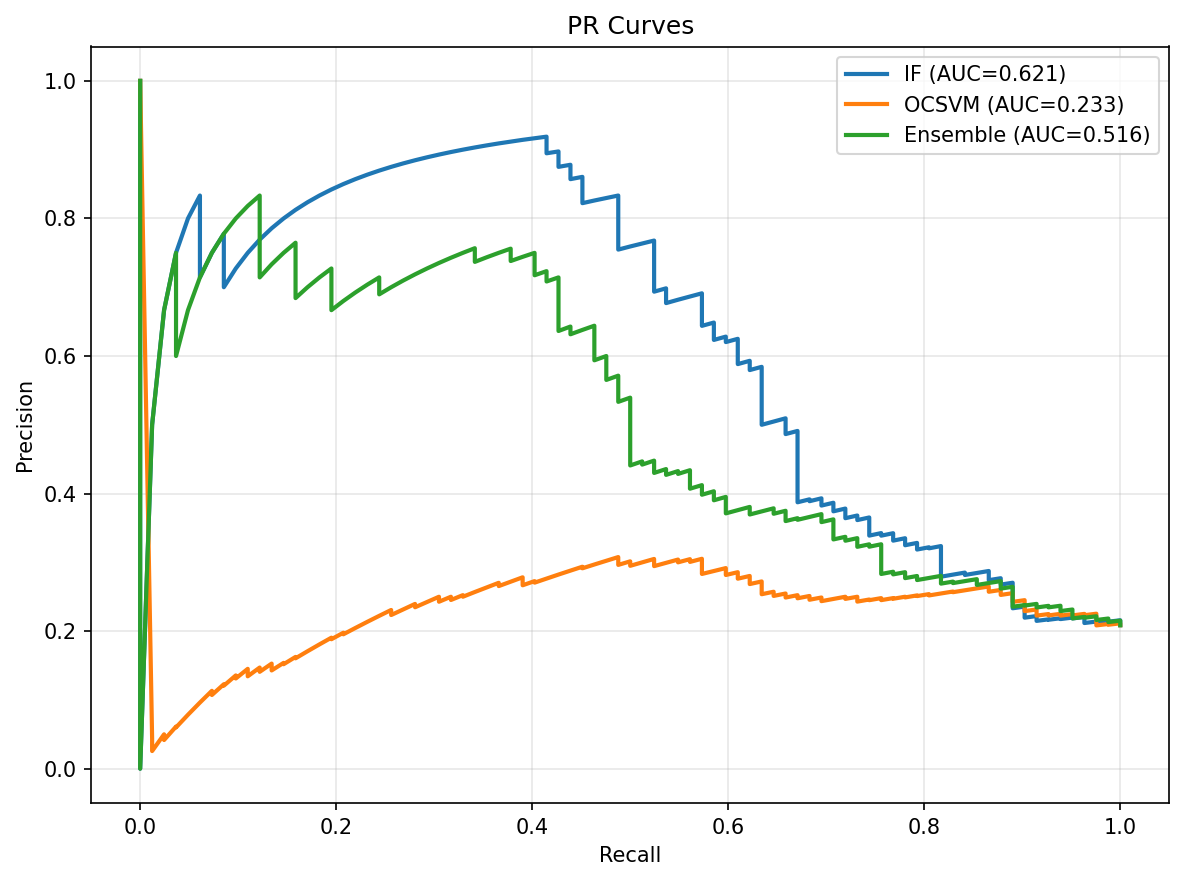

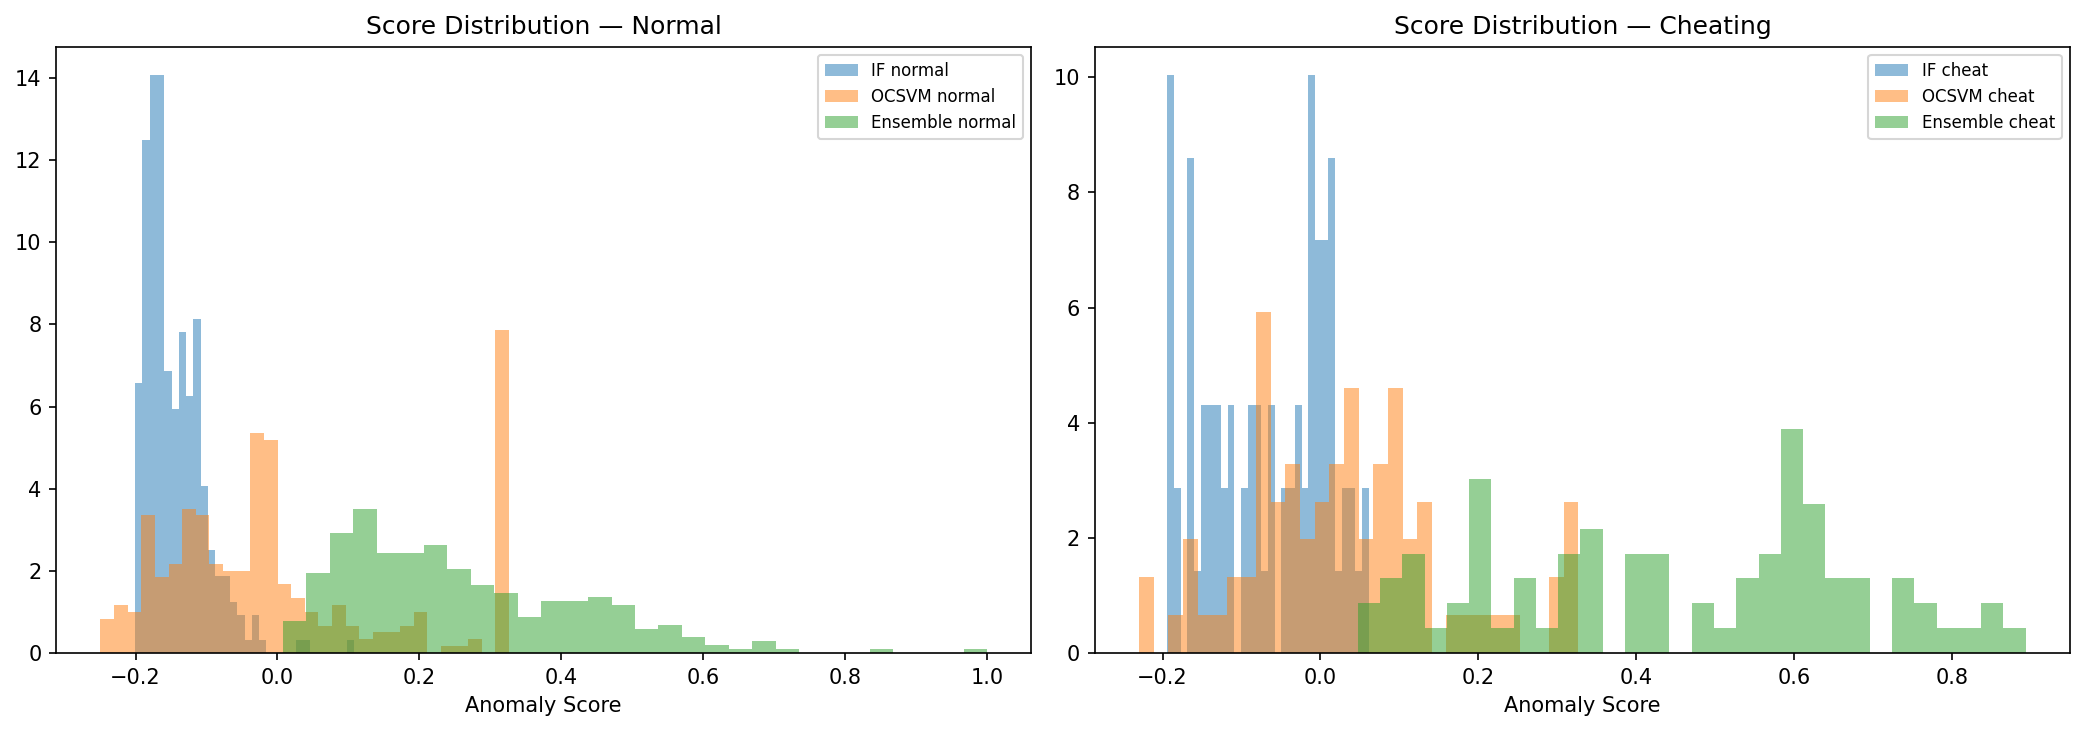

In [4]:
# ============================================================
# Validation — PR Curves & Score Distributions
# ============================================================
plot_pr_curves(val_scores, y_val, VAL_DIR / "pr_curves.png")
display(Image(filename=str(VAL_DIR / "pr_curves.png")))

plot_score_distributions(val_scores, y_val, VAL_DIR / "score_distributions.png")
display(Image(filename=str(VAL_DIR / "score_distributions.png")))

In [5]:
# ============================================================
# Final Evaluation — Test Set
# ============================================================
results["metrics_df"]

best_name = results["best_name"]
best_pr_auc = results["metrics_df"].loc[best_name, "pr_auc"]
print(f"=== Best Model: {best_name} (Test PR-AUC = {best_pr_auc:.4f}) ===")

=== Best Model: IF (Test PR-AUC = 0.7578) ===


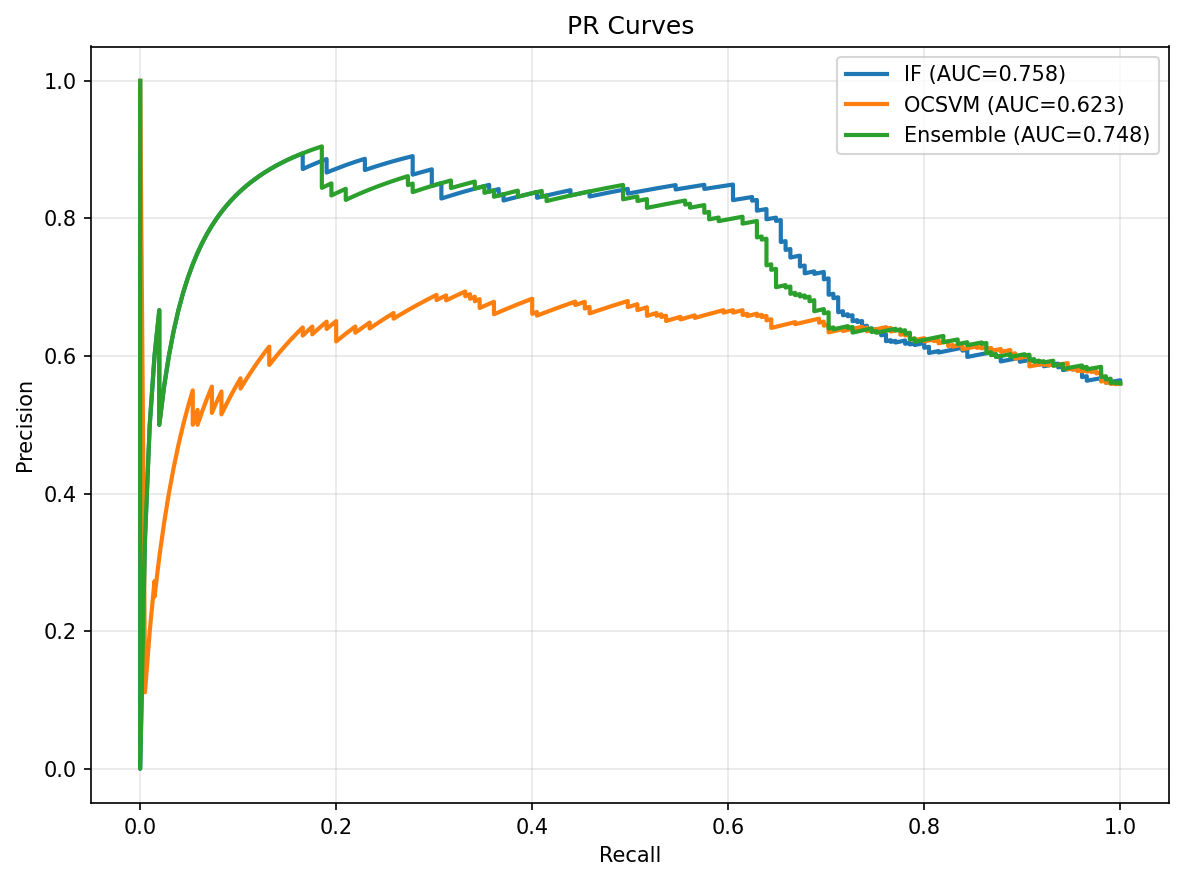

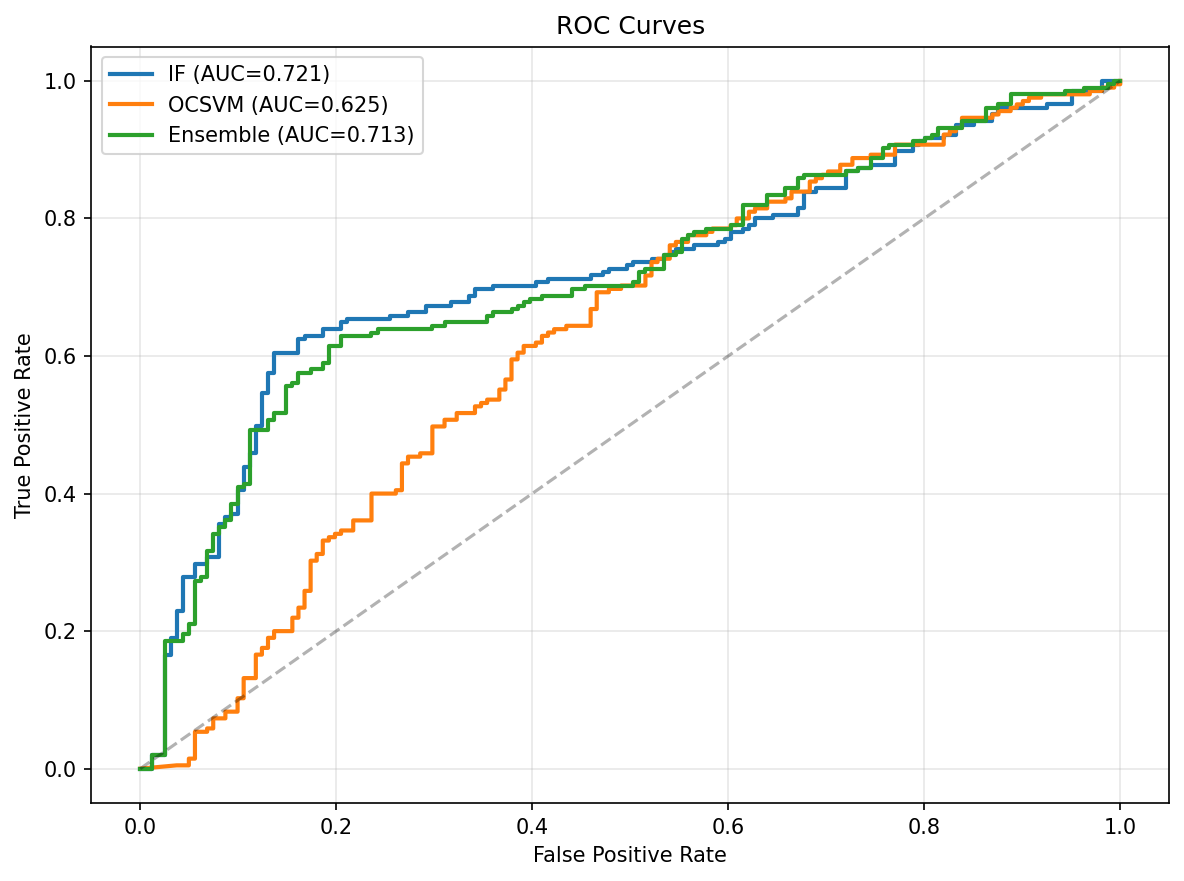

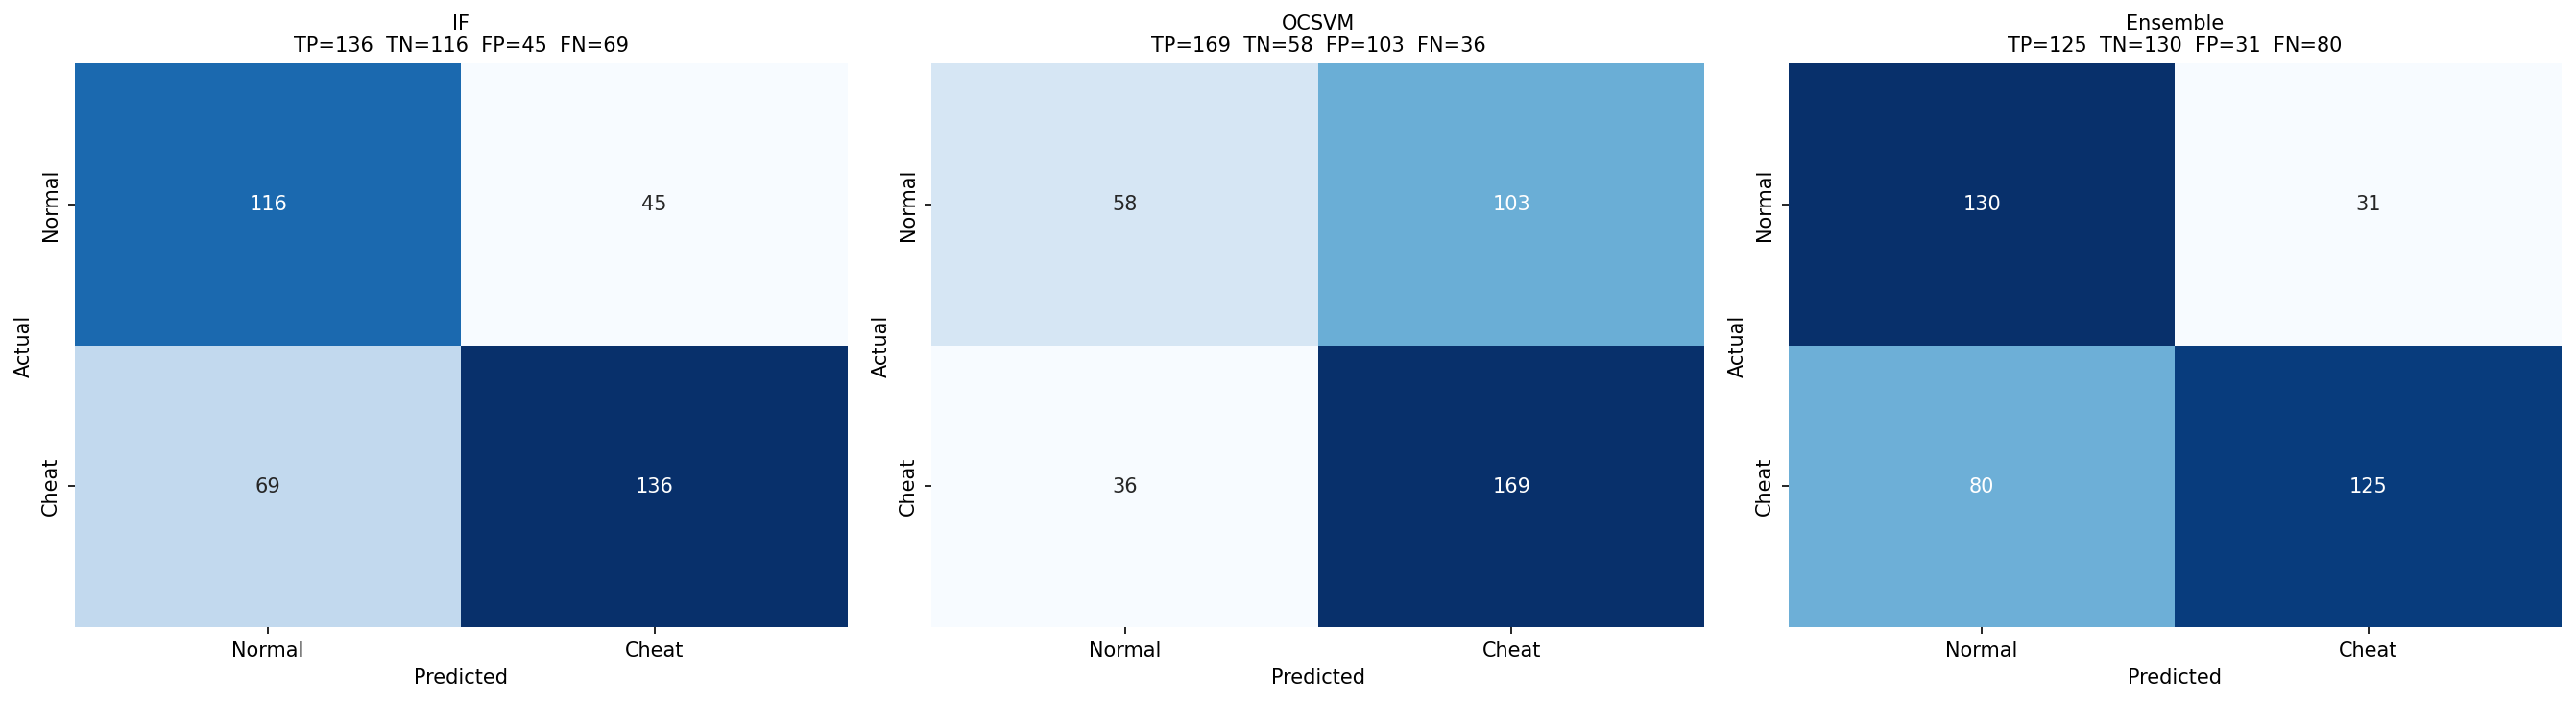

In [6]:
# ============================================================
# Test Plots — PR, ROC, Confusion Matrices
# ============================================================
# plot_pr_curves(test_scores, y_test, TEST_DIR / "pr_curves.png")
display(Image(filename=str(TEST_DIR / "pr_curves.png")))

# plot_roc_curves(test_scores, y_test, TEST_DIR / "roc_curves.png")
display(Image(filename=str(TEST_DIR / "roc_curves.png")))

# plot_confusion_matrices(test_results, TEST_DIR / "confusion_matrices.png")
display(Image(filename=str(TEST_DIR / "confusion_matrices.png")))